<a href="https://colab.research.google.com/github/droyktton/ICNPG/blob/master/Clases/Clases_aleatorios/MiniIsing/ICNPG_miniIsing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Modelo de Ising bidimensional

El ejemplo resuelve el modelo de Ising con el metodo de metropolis MonteCarlo. Es decir, genera una cadena de Markov que samplea configuraciones
$\{S_1,...,S_N\}$ con energías

$$H = - \sum_{<ij>} S_i S_j$$

donde $\sum_{<ij>}$ denota suma sobre pares de primeros vecinos,
y $S_i=\pm 1$ el "spin". El método de Monte Carlo garantiza
que para un número de "updates" lo suficientemente grande,
las configuraciones son sampleadas según su peso de Boltzmann

$$P\sim \exp[-H/k_B T]$$

permitiendo hacer promedios termodinámicos de equilibrio. En particular, la magnetización por sitio en función de la temperatura

$$M = \sum_i S_i/N$$

con $N=L \times L$ el numero total de sitios en una
red cuadrada de lado $L$.

La estrategia de paralelización es la del tablero de ajedrez: hacemos updates paralelos, de todas las fichas blancas primero, seguido por el de todas las negras, para evitar condiciones de carrera. Se puede demostrar que esta cadena de Markov converge a equilibrio térmico.

Referencias
* [GPU accelerated Monte Carlo simulations of lattice spin models](https://www.sciencedirect.com/science/article/pii/S1875389211003373)
* [A Performance Study of the 2D Ising Model on GPUs
](https://arxiv.org/abs/1906.06297)
* [Repo con ejemplo parecido, pero sin usar Thrust, solo CUDA C/C++. Incluye versión python](https://github.com/NVIDIA/ising-gpu/tree/master)

In [ ]:
#@title Si no queremos usar curand, y usar un buen generador portable CPU/GPU
!git clone https://github.com/DEShawResearch/random123.git

Cloning into 'random123'...
remote: Enumerating objects: 2422, done.
remote: Counting objects: 100% (2422/2422), done.
remote: Compressing objects: 100% (374/374), done.
remote: Total 2422 (delta 2070), reused 2342 (delta 1992), pack-reused 0
Receiving objects: 100% (2422/2422), 1.98 MiB | 4.98 MiB/s, done.
Resolving deltas: 100% (2070/2070), done.


In [ ]:
#@title timers y macros
%%writefile timers.h

// cronometro para procesos en CPU
// USO: cpu_timer T; T.tic();...calculo...;T.tac(); cout << T.ms_elapsed << "ms\n";

#pragma once

#include <ctime>

struct timespec diff(timespec start, timespec end)
{
        timespec temp;
       	if ((end.tv_nsec-start.tv_nsec)<0) {
                temp.tv_sec = end.tv_sec-start.tv_sec-1;
                temp.tv_nsec = 1000000000+end.tv_nsec-start.tv_nsec;
        } else {
                temp.tv_sec = end.tv_sec-start.tv_sec;
                temp.tv_nsec = end.tv_nsec-start.tv_nsec;
        }
        return temp;
}

struct cpu_timer{
        struct timespec time1, time2;
	double ms_elapsed;

        cpu_timer(){
        	tic();
        }
       ~cpu_timer(){}

        void tic(){
                clock_gettime(CLOCK_PROCESS_CPUTIME_ID, &time1);
        }
        double tac(){
                clock_gettime(CLOCK_PROCESS_CPUTIME_ID, &time2);
                return(ms_elapsed=elapsed());
        }
        double elapsed(){
            return (double)diff(time1,time2).tv_sec*1000 + (double)diff(time1,time2).tv_nsec*0.000001;
        }
};

#define CRONOMETRAR_CPU( X,VECES ) {  { \
                            cpu_timer t; \
			    float msacum=0.0;\
			    float msacum2=0.0;\
			    for(int n=0;n<VECES;n++){\
			    	t.tic();\
                            	X; t.tac();\
				msacum+=t.ms_elapsed;\
				msacum2+=(t.ms_elapsed*t.ms_elapsed);\
			    }\
			    std::cout << "CPU: " << (msacum/VECES) << " +- " << \
			    (sqrt(msacum2/VECES - msacum*msacum/VECES/VECES)) \
			    << " ms (" << VECES << " veces)\n"; \
                            }}


// cronometro para procesos en GPU
// USO: gpu_timer T; T.tic();...calculo...;T.tac(); cout << T.ms_elapsed << "ms\n";

#pragma once
#ifdef __CUDACC__

///////////////////////////////// GPU TIMER ////////////////////////////////
// use CUDA's high-resolution timers when possible
/*
#include <cuda_runtime_api.h>
#include <thrust/system/cuda/error.h> //previous thrust releases
#include <thrust/system_error.h>
#include <string>
void HANDLE_ERROR(cudaError_t error, const std::string& message = "")
{
  if(error)
    throw thrust::system_error(error, thrust::cuda_category(), message);
}
*/

/*
 *
 *      From CUDA By Example An Introduction to General-Purpose GPU Programming”
 *  by Jason Sanders and Edward Kandrot, Addison-Wesley, Upper Saddle River, NJ, 2011
 *
 */

// Macro for handle errors
#include<stdio.h>
__host__ static void HandleError(cudaError_t err, const char *file, int line)
{
    if (err != cudaSuccess) {
        printf("%s in %s at line %d\n", cudaGetErrorString(err), file, line);
        exit(EXIT_FAILURE);
    }
}
#define HANDLE_NULL( a ) {if (a == NULL) { \
                            printf( "Host memory failed in %s at line %d\n", \
                                    __FILE__, __LINE__ ); \
                            exit( EXIT_FAILURE );}}
#define HANDLE_ERROR( err ) (HandleError( err, __FILE__, __LINE__ ))



/* Function to check for CUDA runtime errors */
static void checkCUDAError(const char* msg) {
	/* Get last error */
    cudaError_t err = cudaGetLastError();
    if( cudaSuccess != err) {
    	/* Print the error */
        printf("Cuda error: %s %s\n",msg, cudaGetErrorString( err));
        /* Abort the program */
        exit(EXIT_FAILURE);
    }
}


struct gpu_timer
{
  cudaEvent_t start;
  cudaEvent_t end;
  float ms_elapsed;

  gpu_timer(void)
  {
    HANDLE_ERROR(cudaEventCreate(&start));
    HANDLE_ERROR(cudaEventCreate(&end));
    tic();
  }

  ~gpu_timer(void)
  {
    HANDLE_ERROR(cudaEventDestroy(start));
    HANDLE_ERROR(cudaEventDestroy(end));
  }

  void tic(void)
  {
    HANDLE_ERROR(cudaEventRecord(start, 0));
  }

  double tac(void)
  {
    HANDLE_ERROR(cudaEventRecord(end, 0));
    HANDLE_ERROR(cudaEventSynchronize(end));

    HANDLE_ERROR(cudaEventElapsedTime(&ms_elapsed, start, end));
    return ms_elapsed;
  }

  double epsilon(void)
  {
    return 0.5e-6;
  }
};

#include<iostream>
#define CRONOMETRAR_GPU( X,VECES ) \
			    {  { \
                            gpu_timer t; \
			    float msacum=0.0;\
			    for(int n=0;n<VECES;n++){\
			    	t.tic();\
                            	X; t.tac();\
				msacum+=t.ms_elapsed;\
			    }\
			    std::cout << "GPU: " << (msacum) << \
			    " ms (" << VECES << " veces)\n"; \
                            }}

#endif


Overwriting timers.h


In [ ]:
#@title Modelo de Ising
%%writefile miniIsing.cu

#include<iostream> //input-output pantalla
#include<fstream> //input-output disco
#include<cstdlib> // atoi, atof, etc
#include <unistd.h> // getop
#include <cmath>
#include <string>

//#include "gpu_timer.h"
//#include "cpu_timer.h"
#include "timers.h"

// thrust
#include<thrust/host_vector.h>
#include<thrust/device_vector.h>
#include <thrust/tuple.h>
#include <thrust/transform.h>
#include <thrust/functional.h>
#include <thrust/execution_policy.h>
#include<thrust/iterator/counting_iterator.h>

// definir RANDOM123 para usar en vez de curand
#ifndef RANDOM123

/* counter-based random numbers in curand API */
#include <curand_kernel.h>

#else

/* counter-based random numbers */
// http://www.thesalmons.org/john/random123/releases/1.06/docs/
#include <Random123/philox.h> // philox headers
#include <Random123/uniform.hpp>    // to get uniform deviates [0,1]
typedef r123::Philox2x32 RNG; // particular counter-based RNG

#endif


// functor para obtener numeros aleatorios uniformes en [0,1]
// a partir de un key (sitio), un global seed, y un tiempo

#ifndef RANDOM123

__device__
float uniform(int n, int seed, int t)
{
    curandStatePhilox4_32_10_t s;

    // seed a random number generator
    curand_init(seed,n, t, &s);

    float x = curand_uniform(&s);

    return x;
}

#else

__device__
float uniform(int n, int seed, int t)
{
		// keys and counters
		RNG philox;
		RNG::ctr_type c={{}};
		RNG::key_type k={{}};
		RNG::ctr_type r;
		// Garantiza una secuencia random "unica" para cada thread
		k[0]=n;    // distintos sitios, distintos numeros random!
		c[1]=seed; // seed global, necesario para decidir reproducir secuencia, o no...
		c[0]=t;    // el seed tiene que cambiar con la iteracion, sino...
		r = philox(c, k); // son dos numeros random, usaremos uno solo r[0]
		return (r123::u01<float>(r[0])); // funcion adaptadora a [0,1]
}

#endif

// functor tipo predicado: cada thread determina si su sitio es del "color" 0 o 1
// necesario para "transform_if"
struct ficha
{
	bool color;
	int L;
	ficha(bool _color, int _L):color(_color),L(_L){};

	__device__ __host__
	bool operator()(int n){
		return ((n%L+int(n/L))%2==color); // true si n es color
	}
};

// functor: cada thread hace el metropolis update de su sitio
// ejemplo para modelo de Ising con interaccion de primeros vecinos
struct metropolis
{
	int L;
	float T;
	int *Mptr;
	int t;
	int seed;
	metropolis(int * _Mptr, float _T, int _L, int _t, int _seed):
	Mptr(_Mptr),T(_T),L(_L),t(_t),seed(_seed){};

	__device__
	int operator()(int n){

		int nx=n%L;
	       	int ny=int(n/L);

		int local_field=
		Mptr[(nx-1+L)%L  + ny*L] + Mptr[(nx+1+L)%L  + ny*L] +
		Mptr[nx+((ny+1+L)%L)*L]  + Mptr[nx+((ny-1+L)%L)*L];

		// contribucion de nuestro spin sin flipear a la energia
		float ene0=-Mptr[n]*local_field;

		// contribucion a la energia de nuestro spin flipeado
		float ene1=Mptr[n]*local_field;

		// metropolis: aceptar flipeo solo si r < exp(-(ene1-ene0)/temp)
		float p=exp(-(ene1-ene0)/T);

		// numero random entre [0,1] uniforme
		float rn = uniform(n, seed, t);

		// metropolis update segun regla de acceptancia
		return (rn<p)?(-Mptr[n]):(Mptr[n]);
	}
};

// imprime toda la red de sitios en pantalla
void print_campo_de_magnetizacion(thrust::device_vector<int> &M, int L, int nt)
{
	std::fstream fout;
	std::string filename = "movie";
	std::string s = std::to_string(nt);
	std::string s2 = ".dat";
	filename = filename + s + s2;
	fout.open(filename, std::ios::app);

	for(int ny=0;ny<L;ny++){
		for(int nx=0;nx<L;nx++){
			fout << M[nx+ny*L] << "\t";
		}
		fout << std::endl;
	}
}

/*
COMPILACION:
nvcc miniising.cu
*/
int main(int argc, char **argv)
{
	int globalseed=123456; // semilla global generador paralelo
	int L=512; // largo red cuadrada
	float T=1.0; // temperatura
	int nrun=1000; // numero total de pasos de MonteCarlo
	int tsnap=nrun+1; // cada cuando imprimo configs
	std::ofstream mout("mag.dat"); // fichero para guardar magnetizacion por sitio vs tiempo

	// para tomar opciones de la linea de comandos
	int opt;
	while ((opt = getopt(argc, argv, "l:r:T:s:w:")) != -1)
	{
               switch (opt) {
               case 'l':
                   L = atoi(optarg);
                   break;
               case 'r':
                   nrun = atoi(optarg);
                   break;
               case 'T':
                   T = atof(optarg);
                   break;
               case 's':
                   globalseed = atoi(optarg);
                   break;
               case 'w':
                   tsnap = atoi(optarg);
                   break;
               default: /* '?' */
                   fprintf(stderr, "Uso: %s [-l L] [-r niter] [-T temp] [-s semilla] [-w snap]\n", argv[0]);
                   exit(EXIT_FAILURE);
               }
	}

	std::ofstream logout("log.dat"); // fichero para guardar configs
	logout << "L=" << L << ", ";
	logout << "nrun=" << nrun << ", ";
	logout << "T=" << T << ", ";
	logout << "globalseed= " << globalseed << " ";
	logout << "tsnap= " << tsnap << "\n";
	std::cout << "L=" << L << ", ";
	std::cout << "nrun=" << nrun << ", ";
	std::cout << "T=" << T << ", ";
	std::cout << "globalseed= " << globalseed << " ";
	std::cout << "tsnap= " << tsnap << "\n";

#ifdef __CUDACC__
  int card;
  cudaGetDevice(&card);
  cudaDeviceProp deviceProp;
  cudaGetDeviceProperties(&deviceProp, card);
  logout << "\nDevice Selected " << card << " " << deviceProp.name << "\n";
	std::cout << "\nDevice Selected " << card << " " << deviceProp.name << "\n";
#else
	std::cout << "\nrun in CPU " << "\n";
#endif

	/**************************************************/
	// AHORA EMPIEZA LO IMPORTANTE


	if(L%2==1) std::cout << "warning: para usar checkerboard L debe ser par" << std::endl;

	int N=L*L;

	// vector de magnetizacion en la red
	thrust::device_vector<int> M(N);
	int *Mraw=thrust::raw_pointer_cast(M.data()); // puntero crudo

	// condicion inicial random, usando generador standard de C
	for(int n=0;n<N;n++) M[n]=(rand()*1.0/RAND_MAX>0.5)?(1):(-1);


	cpu_timer crono;
	crono.tic();

	// loop de pasos de MonteCarlo
	for(int nt=0;nt<nrun;nt++)
	{
		//ojo!: lento, GPU->CPU->disco de mucha info! (hacer cada muchos pasos)
		if((nt)%tsnap==0) print_campo_de_magnetizacion(M, L, nt);

		// imprime magnetizacion por sitio (usando parallel reduction)
		mout << nt << " " << thrust::reduce(M.begin(),M.end())*1.0/N << std::endl;

		for(int color=0;color<2;color++){ // "checkerboard decomposition"
			// update de sitios de color "color" usando transform_if paralelo
			thrust::transform_if(
				thrust::make_counting_iterator(0), thrust::make_counting_iterator(N), //rango
				M.begin(), // output
				metropolis(Mraw,T,L,nt,globalseed), // operacion
				ficha(color, L) // predicado
			);
		}
	}

	std::cout << "ejecutable = " << argv[0] << std::endl;
	std::cout << "ms = " << crono.tac() << std::endl;


	logout << "ejecutable = " << argv[0] << std::endl;
	logout << "tiempo de ejecución [ms] = " << crono.tac() << std::endl;


	return 0;
}




Overwriting miniIsing.cu


In [ ]:
!nvcc miniIsing.cu -o miniIsing

Corrida con parámetros de la línea de comandos

* -l tamaño
* -r número_total_de_pasos_de_MC
* -T temperatura
* -s semilla_aleatorios
* -w cada_cuanto_graba_configuración

Para medir performance poner parámetro de "-w" de tal forma de que no imprima ninguna configuración durante la corrida: "número_total_de_pasos_de_MC < cada_cuanto_graba_configuración".

In [ ]:
!./miniIsing -l 512 -r 1000 -T 2.0 -s 123456 -w 100

L=512, nrun=1000, T=2, globalseed= 123456 tsnap= 100

Device Selected 0 Tesla T4
ejecutable = ./miniIsing
ms = 25323.2


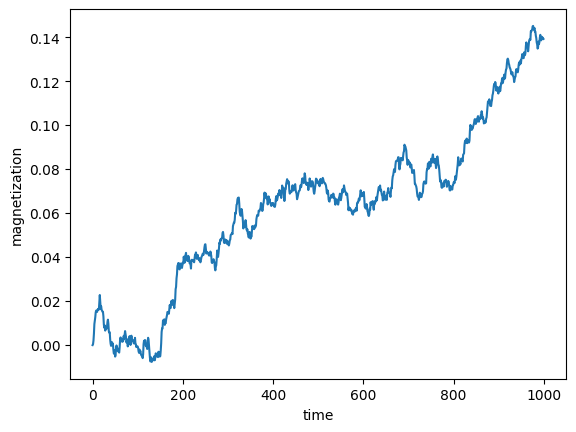

In [ ]:
# prompt: plot the file "mag.dat" with xlabel='time' and ylabel='magnetization
# '

import numpy as np
import matplotlib.pyplot as plt

def plot_magnetization():
  # Load the data from the file
  data = np.loadtxt('mag.dat')

  # Extract the time and magnetization columns
  time = data[:, 0]
  magnetization = data[:, 1]

  # Plot the data
  plt.plot(time, magnetization)

  # Set the labels
  plt.xlabel('time')
  plt.ylabel('magnetization')

  # Show the plot
  plt.show()

plot_magnetization()

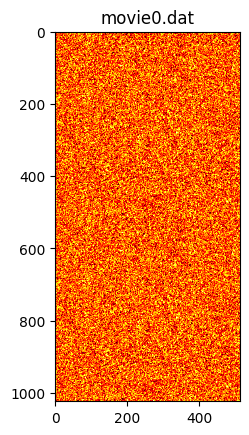

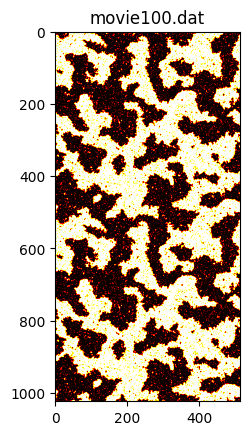

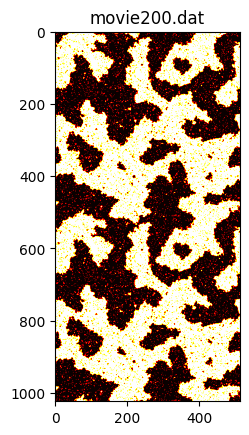

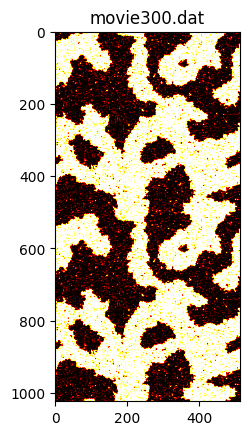

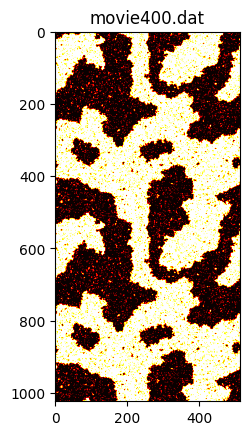

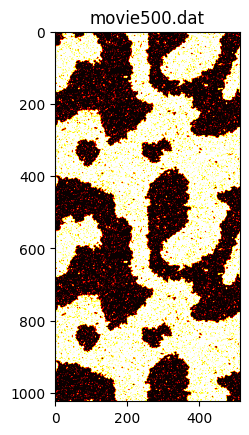

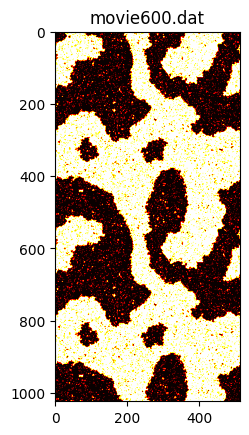

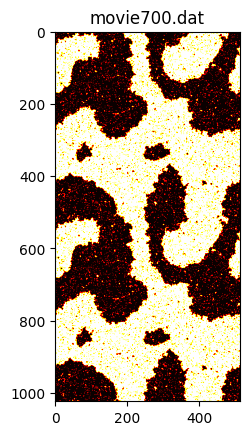

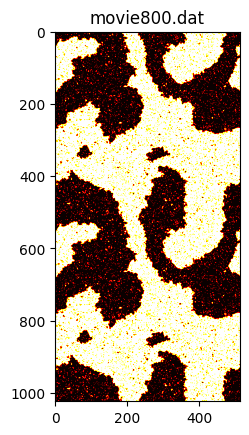

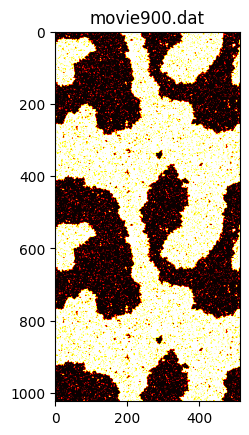

In [ ]:
# prompt: Plot all files named movie0.dat, movie100.dat movie200.dat, etc, up to movie900.dat as heat maps and put the filename as titles.

import matplotlib.pyplot as plt
import numpy as np

def plot_movie():
  # Define the range of files to load
  file_range = range(0, 901, 100)

  # Loop through the files and plot them
  for i in file_range:
      # Load the data from the file
      data = np.loadtxt(f'movie{i}.dat')

      # Create the heat map
      plt.imshow(data, cmap='hot')

      # Set the title
      plt.title(f'movie{i}.dat')

      # Show the plot
      plt.show()

plot_movie()

In [ ]:
!rm movie*.dat

# Version portable usando RANDOM123 directamente

In [ ]:
!nvcc miniIsing.cu -o miniIsing -DRANDOM123 -I/content/random123/include

In [ ]:
!./miniIsing -l 512 -r 1000 -T 2.0 -s 123456 -w 100

L=512, nrun=1000, T=2, globalseed= 123456 tsnap= 100

Device Selected 0 Tesla T4
ejecutable = ./miniIsing
ms = 25553.9


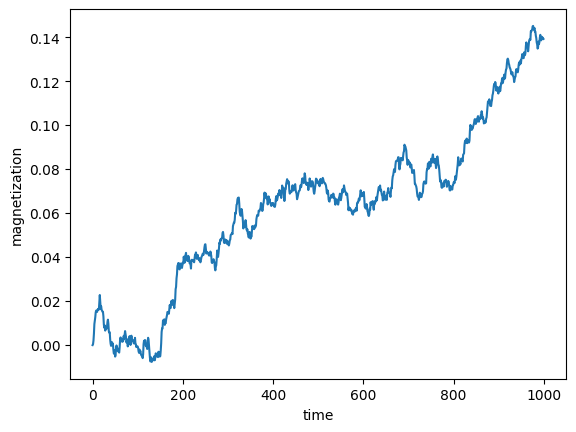

In [ ]:
plot_magnetization()

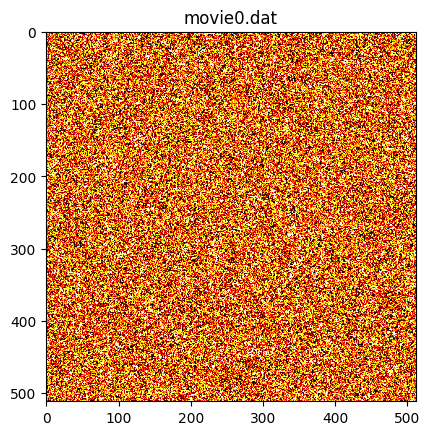

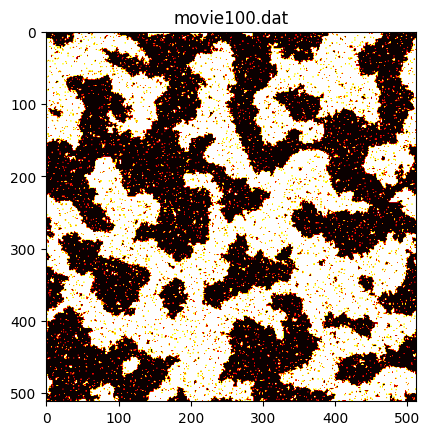

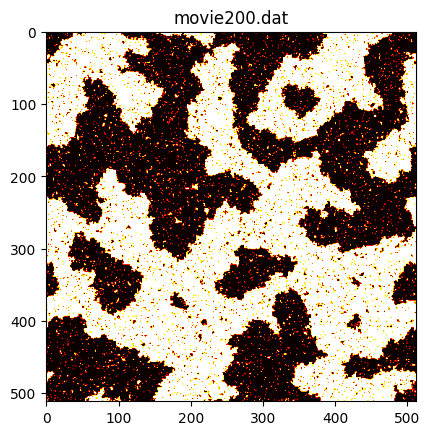

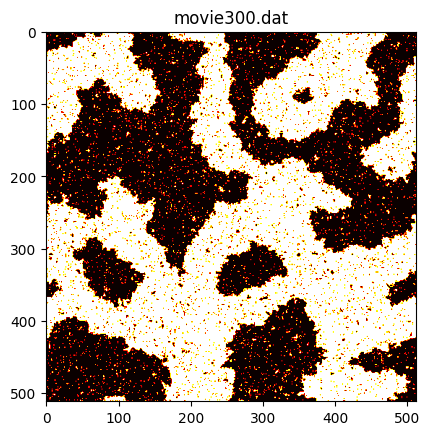

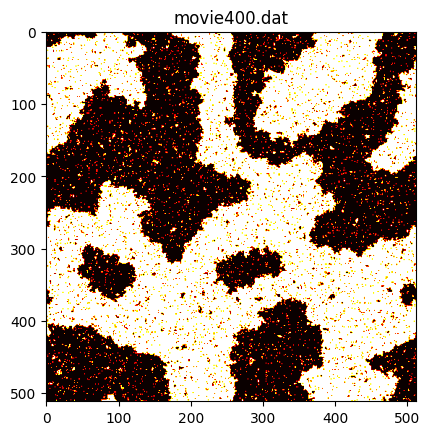

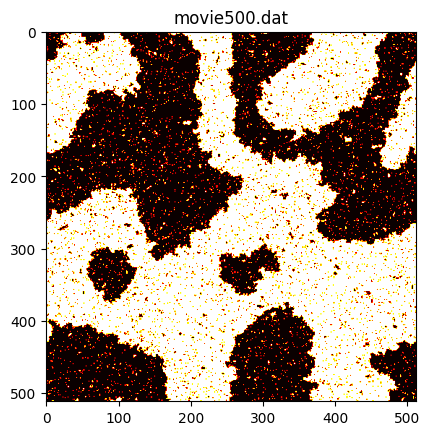

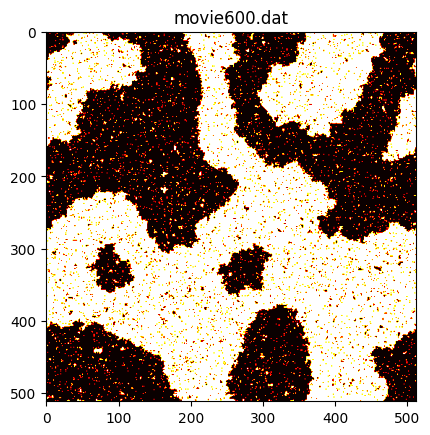

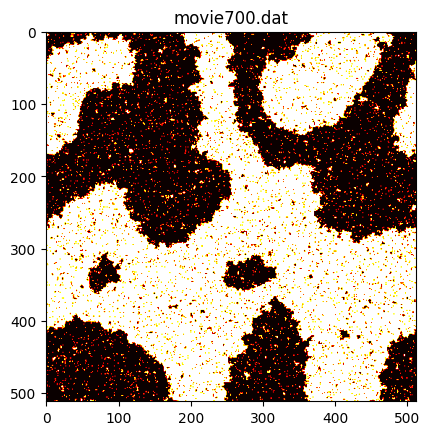

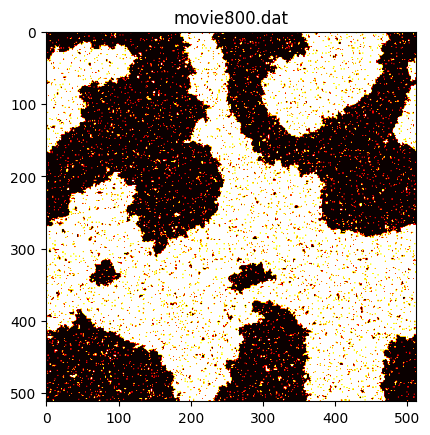

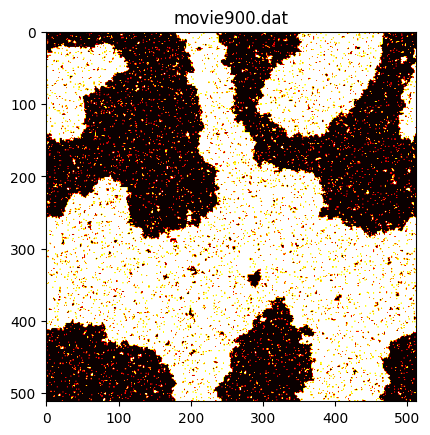

In [ ]:
plot_movie()

# Compilando para GPU o CPU

## CPU

In [ ]:
!cp miniIsing.cu miniIsing.cpp; g++ -O2 miniIsing.cpp -DTHRUST_DEVICE_SYSTEM=THRUST_DEVICE_SYSTEM_CPP -I/usr/local/cuda/include/ -o miniIsingCPU

In [ ]:
!./miniIsingCPU -l 512 -r 1000 -T 2.0 -s 123456 -w 1001

L=512, nrun=1000, T=2, globalseed= 123456 tsnap= 1001

run in CPU 
ejecutable = ./miniIsingCPU
ms = 14682.1


## CPU multicore (openMP)

In [ ]:
!cp miniIsing.cu miniIsing.cpp; g++ -O2 miniIsing.cpp -fopenmp -DTHRUST_DEVICE_SYSTEM=THRUST_DEVICE_SYSTEM_OMP -lgomp -I/usr/local/cuda/include/ -o miniIsingCPUparalelo

In [ ]:
!./miniIsingCPUparalelo -l 512 -r 1000 -T 2.0 -s 123456 -w 1001

L=512, nrun=1000, T=2, globalseed= 123456 tsnap= 1001

run in CPU 
ejecutable = ./miniIsingCPUparalelo
ms = 22088.2


## GPU

In [ ]:
!nvcc miniIsing.cu -o miniIsingR123 -DRANDOM123 -I/content/random123/include

In [ ]:
!./miniIsingR123 -l 512 -r 1000 -T 2.0 -s 123456 -w 1001

L=512, nrun=1000, T=2, globalseed= 123456 tsnap= 1001

Device Selected 0 Tesla T4
ejecutable = ./miniIsingR123
ms = 2705.55


In [ ]:
!nvcc miniIsing.cu -o miniIsing

In [ ]:
!./miniIsing -l 512 -r 1000 -T 2.0 -s 123456 -w 1001

L=512, nrun=1000, T=2, globalseed= 123456 tsnap= 1001

Device Selected 0 Tesla T4
ejecutable = ./miniIsing
ms = 2401.85
